### Apriori Algorithm

The algorithm works by first identifying all the frequent itemsets in a dataset, and then generating association rules from those itemsets. 

These association rules can then be used to make predictions or recommendations based on the patterns and relationships discovered.

In [ ]:
#!pip install mlxtend

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [1]:
import pandas as pd

from mlxtend.preprocessing import TransactionEncoder

from mlxtend.frequent_patterns import apriori, association_rules

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

dataset = [
    ['apple', 'bread', 'milk'],
    ['apple', 'bread', 'diaper', 'milk'],
    ['apple', 'diaper', 'milk'],
    ['bread', 'diaper', 'milk']
]


In [3]:

te = TransactionEncoder()

te_ary = te.fit(dataset).transform(dataset)
te_ary

array([[ True,  True, False,  True],
       [ True,  True,  True,  True],
       [ True, False,  True,  True],
       [False,  True,  True,  True]])

In [4]:
df = pd.DataFrame(te_ary, columns=te.columns_)
df

,apple,bread,diaper,milk
0,True,True,False,True
1,True,True,True,True
2,True,False,True,True
3,False,True,True,True


In [5]:

frequent_itemsets = apriori(df, min_support=0.5, use_colnames=True)

print("Frequent Itemsets:\n", frequent_itemsets)


Frequent Itemsets:
     support               itemsets
0      0.75                (apple)
1      0.75                (bread)
2      0.75               (diaper)
3      1.00                 (milk)
4      0.50         (bread, apple)
5      0.50        (diaper, apple)
6      0.75          (milk, apple)
7      0.50        (diaper, bread)
8      0.75          (milk, bread)
9      0.75         (milk, diaper)
10     0.50   (milk, bread, apple)
11     0.50  (milk, diaper, apple)
12     0.50  (milk, diaper, bread)


In [6]:

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules = rules.dropna(subset=['confidence', 'lift'])
rules


C:\Users\nvgra\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(milk),(apple),1.00,0.75,0.75,0.75,1.0,1.0,0.0,1.0,0.0,0.75,0.0,0.875
1,(apple),(milk),0.75,1.00,0.75,1.00,1.0,1.0,0.0,inf,0.0,0.75,0.0,0.875
2,(milk),(bread),1.00,0.75,0.75,0.75,1.0,1.0,0.0,1.0,0.0,0.75,0.0,0.875
3,(bread),(milk),0.75,1.00,0.75,1.00,1.0,1.0,0.0,inf,0.0,0.75,0.0,0.875
4,(milk),(diaper),1.00,0.75,0.75,0.75,1.0,1.0,0.0,1.0,0.0,0.75,0.0,0.875
5,(diaper),(milk),0.75,1.00,0.75,1.00,1.0,1.0,0.0,inf,0.0,0.75,0.0,0.875
6,"(bread, apple)",(milk),0.50,1.00,0.50,1.00,1.0,1.0,0.0,inf,0.0,0.50,0.0,0.750
7,(milk),"(bread, apple)",1.00,0.50,0.50,0.50,1.0,1.0,0.0,1.0,0.0,0.50,0.0,0.750
8,"(diaper, apple)",(milk),0.50,1.00,0.50,1.00,1.0,1.0,0.0,inf,0.0,0.50,0.0,0.750
9,(milk),"(diaper, apple)",1.00,0.50,0.50,0.50,1.0,1.0,0.0,1.0,0.0,0.50,0.0,0.750


In [7]:
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(milk),(apple),1.00,0.75,0.75,0.75,1.0,1.0,0.0,1.0,0.0,0.75,0.0,0.875
1,(apple),(milk),0.75,1.00,0.75,1.00,1.0,1.0,0.0,inf,0.0,0.75,0.0,0.875
2,(milk),(bread),1.00,0.75,0.75,0.75,1.0,1.0,0.0,1.0,0.0,0.75,0.0,0.875
3,(bread),(milk),0.75,1.00,0.75,1.00,1.0,1.0,0.0,inf,0.0,0.75,0.0,0.875
4,(milk),(diaper),1.00,0.75,0.75,0.75,1.0,1.0,0.0,1.0,0.0,0.75,0.0,0.875
5,(diaper),(milk),0.75,1.00,0.75,1.00,1.0,1.0,0.0,inf,0.0,0.75,0.0,0.875
6,"(bread, apple)",(milk),0.50,1.00,0.50,1.00,1.0,1.0,0.0,inf,0.0,0.50,0.0,0.750
7,(milk),"(bread, apple)",1.00,0.50,0.50,0.50,1.0,1.0,0.0,1.0,0.0,0.50,0.0,0.750
8,"(diaper, apple)",(milk),0.50,1.00,0.50,1.00,1.0,1.0,0.0,inf,0.0,0.50,0.0,0.750
9,(milk),"(diaper, apple)",1.00,0.50,0.50,0.50,1.0,1.0,0.0,1.0,0.0,0.50,0.0,0.750


In [8]:

top_rules = rules.head(5)
print("\nTop Association Rules by Lift:")
print(top_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])



Top Association Rules by Lift:
  antecedents consequents  support  confidence  lift
0      (milk)     (apple)     0.75        0.75   1.0
1     (apple)      (milk)     0.75        1.00   1.0
2      (milk)     (bread)     0.75        0.75   1.0
3     (bread)      (milk)     0.75        1.00   1.0
4      (milk)    (diaper)     0.75        0.75   1.0


C:\Users\nvgra\AppData\Local\Temp\ipykernel_25260\262082086.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='lift', y=top_rules.index, data=top_rules, palette="viridis")


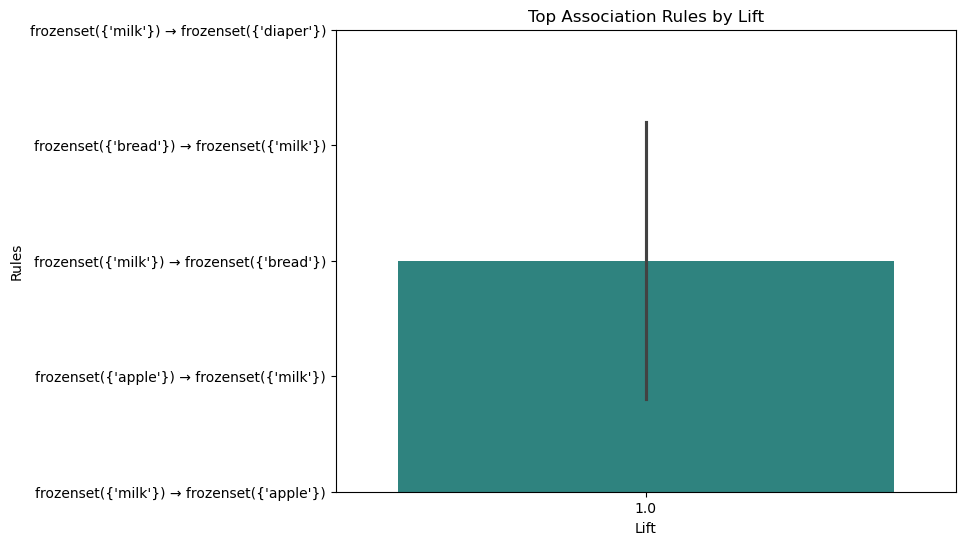

In [9]:

plt.figure(figsize=(8,6))
sns.barplot(x='lift', y=top_rules.index, data=top_rules, palette="viridis")
plt.yticks(top_rules.index, top_rules['antecedents'].astype(str) + " → " + top_rules['consequents'].astype(str))
plt.xlabel('Lift')
plt.ylabel('Rules')
plt.title('Top Association Rules by Lift')
plt.show()


In [10]:

print("\nInsights / Recommendations:")
for idx, row in top_rules.iterrows():
    print(f"- If a customer buys {list(row['antecedents'])}, they are likely to buy {list(row['consequents'])} "
          f"(Confidence: {row['confidence']:.2f}, Lift: {row['lift']:.2f})")



Insights / Recommendations:
- If a customer buys ['milk'], they are likely to buy ['apple'] (Confidence: 0.75, Lift: 1.00)
- If a customer buys ['apple'], they are likely to buy ['milk'] (Confidence: 1.00, Lift: 1.00)
- If a customer buys ['milk'], they are likely to buy ['bread'] (Confidence: 0.75, Lift: 1.00)
- If a customer buys ['bread'], they are likely to buy ['milk'] (Confidence: 1.00, Lift: 1.00)
- If a customer buys ['milk'], they are likely to buy ['diaper'] (Confidence: 0.75, Lift: 1.00)


### FP-Growth Algorithm

In large datasets, FP-growth is a popular method for mining frequent item sets.

It generates frequent itemsets efficiently without generating candidate itemsets using a tree-based data structure called the FP-tree. 
 
As a result, it is faster and more memory efficient than the Apriori algorithm when dealing with large datasets. 

First, the algorithm constructs an FP-tree from the input dataset, then recursively generates frequent itemsets from it.

In [ ]:

import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules
import matplotlib.pyplot as plt
import seaborn as sns

dataset = [
    ['apple', 'bread', 'milk'],
    ['apple', 'bread', 'diaper', 'milk'],
    ['apple', 'diaper', 'milk'],
    ['bread', 'diaper', 'milk']
]

te = TransactionEncoder()
te_ary = te.fit(dataset).transform(dataset)
df = pd.DataFrame(te_ary, columns=te.columns_)

frequent_itemsets = fpgrowth(df, min_support=0.5, use_colnames=True)
print("Frequent Itemsets:\n", frequent_itemsets)

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules = rules.dropna(subset=['confidence', 'lift'])  # remove NaN
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)


In [ ]:

# Display top rules by lift
top_rules = rules.head(5)
print("\nTop Association Rules by Lift:")
print(top_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])


In [ ]:

plt.figure(figsize=(8,6))
sns.barplot(x='lift', y=top_rules.index, data=top_rules, palette="viridis")
plt.yticks(top_rules.index, top_rules['antecedents'].astype(str) + " → " + top_rules['consequents'].astype(str))
plt.xlabel('Lift')
plt.ylabel('Rules')
plt.title('Top Association Rules by Lift (FP-Growth)')
plt.show()

In [ ]:

# Step 7: Insights
print("\nInsights / Recommendations:")
for idx, row in top_rules.iterrows():
    print(f"- If a customer buys {list(row['antecedents'])}, they are likely to buy {list(row['consequents'])} "
          f"(Confidence: {row['confidence']:.2f}, Lift: {row['lift']:.2f})")
